In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -- Load data ---------------------------------------------------------------
data = np.loadtxt("data/training_data.csv", delimiter=",", skiprows=1)
with open("data/training_data.csv") as f:
    header = f.readline().strip().split(",")

feature_names = header[:-1]
X = data[:, :-1]
y = data[:, -1]
print(f"{X.shape[0]} samples, {X.shape[1]} features")
print(f"Score range: [{y.min():.0f}, {y.max():.0f}], mean={y.mean():.2f}")

5000 samples, 35 features
Score range: [0, 26], mean=12.53


In [2]:
# -- Train/test split --------------------------------------------------------
rng = np.random.RandomState(42)
indices = rng.permutation(len(y))
split = int(len(y) * 0.8)
X_train, X_test = X[indices[:split]], X[indices[split:]]
y_train, y_test = y[indices[:split]], y[indices[split:]]

# -- Ridge regression (alpha=10, matching train_eval.py) ---------------------
ones_train = np.ones((X_train.shape[0], 1))
X_aug = np.hstack([ones_train, X_train])
n_features = X_aug.shape[1]
alpha = 10.0
reg = alpha * np.eye(n_features)
reg[0, 0] = 0  # don't regularize bias
weights = np.linalg.solve(X_aug.T @ X_aug + reg, X_aug.T @ y_train)

# -- Predict on test set ----------------------------------------------------
ones_test = np.ones((X_test.shape[0], 1))
y_pred = np.hstack([ones_test, X_test]) @ weights

# -- Metrics -----------------------------------------------------------------
ss_res = np.sum((y_test - y_pred) ** 2)
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - ss_res / ss_tot
mae = np.mean(np.abs(y_test - y_pred))
print(f"Ridge (alpha={alpha}):  R²={r2:.4f},  MAE={mae:.3f}")

Ridge (alpha=10.0):  R²=0.4171,  MAE=4.105


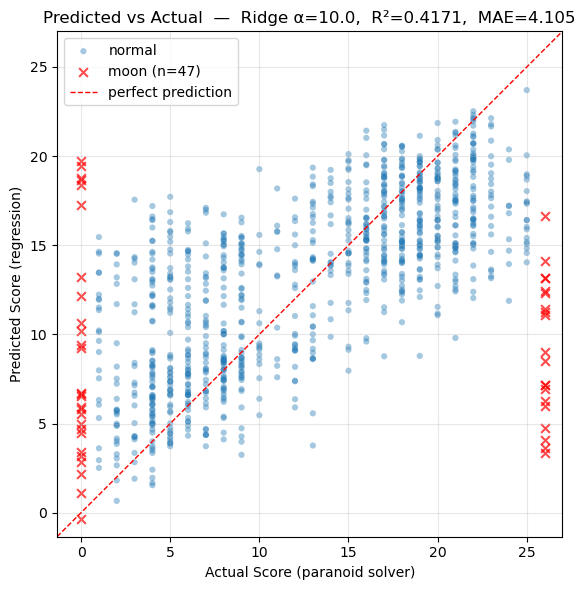

In [5]:
# -- Predicted vs Actual scatterplot (moon-flagged) -------------------------
moon_mask = (y_test == 0) | (y_test == 26)
normal_mask = ~moon_mask

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test[normal_mask], y_pred[normal_mask], alpha=0.4, s=20,
           edgecolors="none", label="normal")
ax.scatter(y_test[moon_mask], y_pred[moon_mask], alpha=0.7, s=40,
           c="red", marker="x", linewidths=1.5,
           label=f"moon (n={moon_mask.sum()})")

lo = min(y_test.min(), y_pred.min()) - 1
hi = max(y_test.max(), y_pred.max()) + 1
ax.plot([lo, hi], [lo, hi], "r--", linewidth=1, label="perfect prediction")

ax.set_xlabel("Actual Score (paranoid solver)")
ax.set_ylabel("Predicted Score (regression)")
ax.set_title(f"Predicted vs Actual  —  Ridge α={alpha},  R²={r2:.4f},  MAE={mae:.3f}")
ax.set_aspect("equal")
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

After moon filter: 4790 samples (removed 210)
Test set: 958, Training pool: 3832
  n=  200: Linear R²=0.5323 MAE=3.729 | Ridge R²=0.5397 MAE=3.728
  n=  500: Linear R²=0.5597 MAE=3.605 | Ridge R²=0.5626 MAE=3.612
  n= 1000: Linear R²=0.5627 MAE=3.602 | Ridge R²=0.5637 MAE=3.605
  n= 1500: Linear R²=0.5594 MAE=3.585 | Ridge R²=0.5606 MAE=3.588
  n= 2000: Linear R²=0.5666 MAE=3.577 | Ridge R²=0.5673 MAE=3.578
  n= 2500: Linear R²=0.5692 MAE=3.578 | Ridge R²=0.5696 MAE=3.579
  n= 3000: Linear R²=0.5694 MAE=3.577 | Ridge R²=0.5699 MAE=3.578
  n= 3500: Linear R²=0.5708 MAE=3.576 | Ridge R²=0.5711 MAE=3.577
  n= 3832: Linear R²=0.5679 MAE=3.573 | Ridge R²=0.5682 MAE=3.574


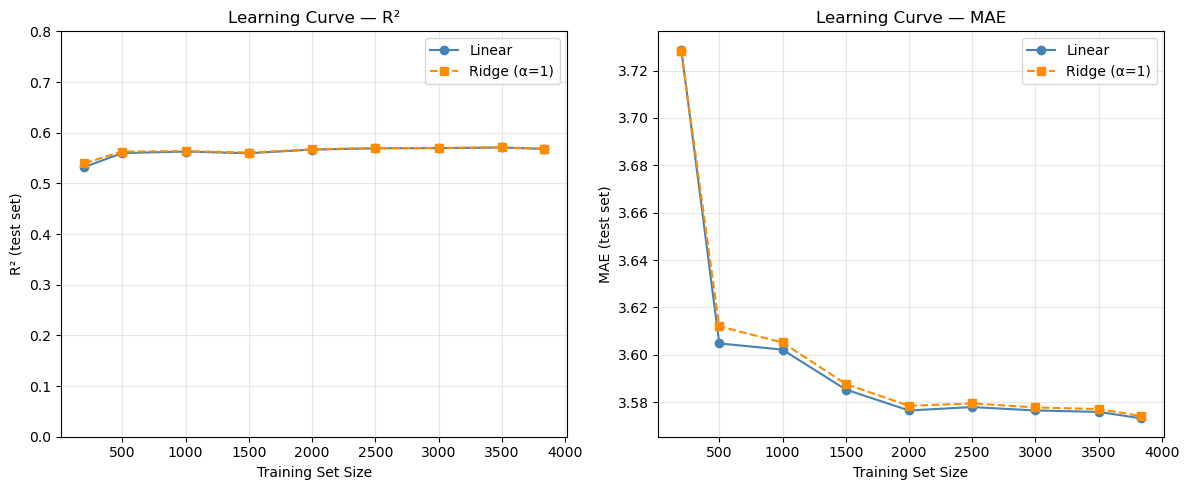


R² slope over last segment: -0.000002 per sample
→ R² has plateaued — more features or a nonlinear model needed (hypothesis 2)


In [6]:
# -- Learning Curve: R² vs Training Set Size ---------------------------------
# Fixed test set (20%), train on increasing subsets to diagnose:
#   - If R² is still climbing at 5K → need more data (hypothesis 1)
#   - If R² plateaus → need more features (hypothesis 2)

from sklearn.linear_model import LinearRegression, Ridge

# Filter moon positions (same as train_eval.py --filter-moon)
moon_mask_all = (y == 0) | (y == 26)
X_nm = X[~moon_mask_all]
y_nm = y[~moon_mask_all]
print(f"After moon filter: {len(y_nm)} samples (removed {moon_mask_all.sum()})")

# Fixed 80/20 split on non-moon data
rng2 = np.random.RandomState(42)
idx = rng2.permutation(len(y_nm))
test_n = int(len(y_nm) * 0.2)
test_idx = idx[:test_n]
train_pool_idx = idx[test_n:]

X_test_nm = X_nm[test_idx]
y_test_nm = y_nm[test_idx]
X_pool = X_nm[train_pool_idx]
y_pool = y_nm[train_pool_idx]

print(f"Test set: {len(y_test_nm)}, Training pool: {len(y_pool)}")

# Train on increasing subsets
sizes = [200, 500, 1000, 1500, 2000, 2500, 3000, 3500, len(y_pool)]
r2_linear = []
r2_ridge = []
mae_linear = []
mae_ridge = []

for n in sizes:
    Xtr = X_pool[:n]
    ytr = y_pool[:n]
    
    # Linear
    lr = LinearRegression().fit(Xtr, ytr)
    pred_lr = lr.predict(X_test_nm)
    ss_res = np.sum((y_test_nm - pred_lr)**2)
    ss_tot = np.sum((y_test_nm - y_test_nm.mean())**2)
    r2_lr = 1 - ss_res / ss_tot
    mae_lr = np.mean(np.abs(y_test_nm - pred_lr))
    r2_linear.append(r2_lr)
    mae_linear.append(mae_lr)
    
    # Ridge
    rr = Ridge(alpha=1.0).fit(Xtr, ytr)
    pred_rr = rr.predict(X_test_nm)
    ss_res = np.sum((y_test_nm - pred_rr)**2)
    r2_rr = 1 - ss_res / ss_tot
    mae_rr = np.mean(np.abs(y_test_nm - pred_rr))
    r2_ridge.append(r2_rr)
    mae_ridge.append(mae_rr)
    
    print(f"  n={n:>5d}: Linear R²={r2_lr:.4f} MAE={mae_lr:.3f} | Ridge R²={r2_rr:.4f} MAE={mae_rr:.3f}")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(sizes, r2_linear, "o-", label="Linear", color="steelblue")
ax1.plot(sizes, r2_ridge, "s--", label="Ridge (α=1)", color="darkorange")
ax1.set_xlabel("Training Set Size")
ax1.set_ylabel("R² (test set)")
ax1.set_title("Learning Curve — R²")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 0.8)

ax2.plot(sizes, mae_linear, "o-", label="Linear", color="steelblue")
ax2.plot(sizes, mae_ridge, "s--", label="Ridge (α=1)", color="darkorange")
ax2.set_xlabel("Training Set Size")
ax2.set_ylabel("MAE (test set)")
ax2.set_title("Learning Curve — MAE")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Verdict
slope = (r2_linear[-1] - r2_linear[-3]) / (sizes[-1] - sizes[-3])
print(f"\nR² slope over last segment: {slope:.6f} per sample")
if slope > 0.00005:
    print("→ R² still climbing meaningfully — more data should help (hypothesis 1)")
else:
    print("→ R² has plateaued — more features or a nonlinear model needed (hypothesis 2)")